<a href="https://colab.research.google.com/github/Rihabd06/portfolio-site/blob/main/cats_vs_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
!unzip /cats_and_dogs_small.zip

Archive:  /cats_and_dogs_small.zip
replace cats_and_dogs_small/test/cats/cat.1500.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cats_and_dogs_small/test/cats/cat.1501.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cats_and_dogs_small/test/cats/cat.1502.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cats_and_dogs_small/test/cats/cat.1503.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cats_and_dogs_small/test/cats/cat.1504.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cats_and_dogs_small/test/cats/cat.1505.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
data_dir = './cats_and_dogs_small'
train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')

In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Load Images Using ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # Resize all images to 150x150
    batch_size=32,
    class_mode='binary'  # Two categories: cat or dog
)

validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:
# Defining a CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
#Training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4877 - loss: 0.9055 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.5528 - loss: 0.6870 - val_accuracy: 0.5990 - val_loss: 0.6748
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.6546 - loss: 0.6428 - val_accuracy: 0.6060 - val_loss: 0.6338
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7025 - loss: 0.5740 - val_accuracy: 0.6580 - val_loss: 0.6127
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7285 - loss: 0.5333 - val_accuracy: 0.6520 - val_loss: 0.6952
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7685 - loss: 0.4656 - val_accuracy: 0.6250 - val_loss: 0.7734
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8053 - loss: 0.4271 - val_accuracy: 0.7140 - val_loss: 0.6407
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8734 - loss: 0.2953 - val_accuracy: 0.7190 - val_loss:

In [ ]:
# Evaluating

test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Error: {1 - test_acc:.4f}")

Test Accuracy: 0.7020 | Test Error: 0.2980


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step
Misclassified 464 out of 1000


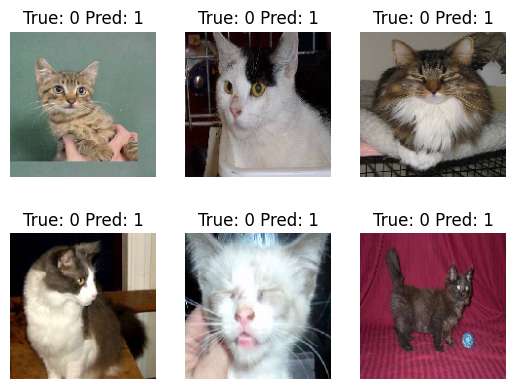

In [ ]:
# Misclassified Images

preds = (model.predict(test_generator) > 0.5).astype(int).squeeze()
true = test_generator.classes
filenames = np.array(test_generator.filenames)

mis_idx = np.where(preds != true)[0]
print(f"Misclassified {len(mis_idx)} out of {len(true)}")

for i in range(min(6, len(mis_idx))):
    idx = mis_idx[i]
    img_path = os.path.join(test_generator.directory, filenames[idx])
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true[idx]} Pred: {preds[idx]}")
    plt.axis('off')

plt.show()